# WILDCARD coin economy study

        ## tl;dr

        - This study contains **7,550 completed deterministic runs across 35 cells**. All recorded invariant and scorer-fidelity checks passed.
        - The best measured Normal payout candidate is a transparent **4 / 4 / 4, then 7 / 7 / 7, then 10 / 10 / 10, then 13 / 13 / 13 coin schedule**, plus a one-time **20-coin Heat-12 completion bonus** (122 coins for a perfect 12-Heat run).
        - Apply that same table on Easy, Medium and Hard; do not add a hidden difficulty payout multiplier. Use the first eight heats for Gauntlet, add a 10-coin full-clear bonus (63 coins), and keep Endless on the same table. Daily remains a competitive mode with no repeatable direct coin payout until score attestation and an idempotent reward ledger exist.
        - The proposed 300 / 600 / 1,500 coin pack ladder at £0.99 / £1.79 / £3.99 is a small test hypothesis, **not** a revenue optimum and not enabled by this study.

        This notebook is a decision aid, not a claim that the game is addictive or that any price will convert. Human playtests and real localized Play offer data remain necessary.

## Context & Methods

        The inputs are the corrected Astra simulator outputs and the source audit in this folder. The simulator uses the native Dart scoring/rule lifecycle, matched deterministic seeds, the phone's card ordering, deck normalization and supply behavior, and explicit invariant/fidelity assertions. It is a strategy-bot study: `handRanking` is a weak baseline, while `adaptive`, `pairBuilder` and `flushBuilder` are policy probes; they are not human populations.

        Payout candidates were selected on even seeds against predeclared targets (about 50 coins for the weak new-player probe and about 90 for the adaptive full-catalogue probe), then checked on odd seeds. The savings table resamples observed per-run rewards independently for 2,000 fixed-collection paths. It excludes one-time tutorial/Journey rewards, ads, purchases, spending, and account-wallet carry-over between different cohorts. Modeled time is an explicit animation/decision-time assumption, not a device benchmark.

        The analysis does not modify game rules, prices, Firebase, ads, billing, Play Games, the phone, or Google Play.

## Data

In [1]:
import csv, json
from pathlib import Path

HERE = Path.cwd()
def read_csv(name):
    with (HERE / name).open(encoding='utf-8-sig', newline='') as f:
        return list(csv.DictReader(f))
summary = json.loads((HERE / 'analysis-summary.json').read_text(encoding='utf-8'))
mode_rows = read_csv('mode-comparison.csv')
schedule_rows = read_csv('recommended-payout-schedule.csv')
life_rows = read_csv('lifecycle-results.csv')
collection_rows = read_csv('collection-results.csv')
print(f"validated runs: {summary['runCount']:,}; mode cells: {summary['cellCount']}")
print(f"mode rows: {len(mode_rows)}; schedule rows: {len(schedule_rows)}; savings rows: {len(life_rows)}; collection strategies: {len(collection_rows)}")

validated runs: 7,550; mode cells: 35
mode rows: 6; schedule rows: 12; savings rows: 12; collection strategies: 3


## Results

In [2]:
print('Mode comparison (recommended schedule unless stated):')
for r in mode_rows:
    print(f"{r['modeLabel']:<24} win={float(r['winRate']):.1%}  mean={float(r['recommendedMeanCoins']):6.1f} coins  {float(r['recommendedCoinsPerMinute']):5.2f}/min  n={r['n']}")

print('\nRecommended Normal schedule:')
print('heat | clear | cumulative before bonus | completion bonus | cumulative')
for r in schedule_rows:
    print(f"{int(r['heat']):>4} | {int(r['clearReward']):>5} | {int(r['cumulativeBeforeCompletionBonus']):>25} | {int(r['completionBonusAtHeat12']):>16} | {int(r['cumulativeReward']):>10}")

Mode comparison (recommended schedule unless stated):
Normal Easy              win=64.4%  mean= 107.4 coins  12.52/min  n=250
Normal Medium            win=26.0%  mean=  83.9 coins   9.32/min  n=250
Normal Hard              win=13.2%  mean=  69.7 coins   7.96/min  n=250
Gauntlet                 win=16.0%  mean=  33.5 coins   5.57/min  n=150
Daily Challenge          win=8.7%  mean=   0.0 coins   0.00/min  n=150
Normal Medium baseline   win=10.0%  mean=  26.9 coins   3.30/min  n=250

Recommended Normal schedule:
heat | clear | cumulative before bonus | completion bonus | cumulative
   1 |     4 |                         4 |                0 |          4
   2 |     4 |                         8 |                0 |          8
   3 |     4 |                        12 |                0 |         12
   4 |     7 |                        19 |                0 |         19
   5 |     7 |                        26 |                0 |         26
   6 |     7 |                        33 |       

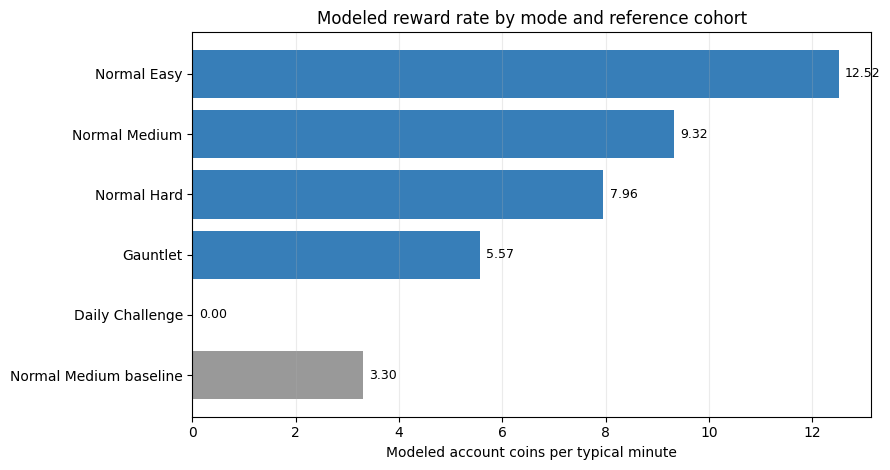

In [3]:
# Native matplotlib chart: a compact comparison of modeled reward rate.
import matplotlib.pyplot as plt

labels = [r['modeLabel'] for r in mode_rows]
values = [float(r['recommendedCoinsPerMinute']) for r in mode_rows]
colors = ['#377eb8' if 'baseline' not in r['modeLabel'] else '#999999' for r in mode_rows]
fig, ax = plt.subplots(figsize=(9, 4.8))
y = list(range(len(labels)))
ax.barh(y, values, color=colors)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlabel('Modeled account coins per typical minute')
ax.set_title('Modeled reward rate by mode and reference cohort')
ax.grid(axis='x', alpha=0.25)
for i, v in enumerate(values):
    ax.text(v + 0.12, i, f'{v:.2f}', va='center', fontsize=9)
fig.tight_layout()
plt.show()

### Savings and collection context

        The savings paths show how the schedule feels at the first purchase, rather than only its mean. A new Medium probe reaches a 100-coin Wood Vault in a median of about two runs and a 300-coin Gold Vault in about four; the full-catalogue Medium probe is similar. Gauntlet's shorter run is intentionally slower to a Vault and therefore should not be used as the primary farming lane. The fixed-collection sampler completes the remaining catalogue at 10,400 coins on a wood-first route (85 Wood and 7 Gold Vaults), while mixed and gold-first routes cost more because WILD rewards are Gold-only.

        The ladder is therefore kept modest: 300 coins, 600 coins and 1,500 coins. These quantities divide cleanly into the standard 100-coin Wood and 300-coin Gold Vaults, but the prices are a hypothesis that must be tested with real localized offers. Existing product IDs, unfinished purchases and entitlements would need a separate release migration; none is performed here.

In [4]:
print('Savings path medians (runs to afford one Vault; fixed cohort resampling):')
for r in life_rows:
    print(f"{r['cohort']:<24} {r['target']:<10} median={r['medianRuns']!s:<4} p10={r['p10Runs']!s:<4} p90={r['p90Runs']!s:<4} mean-lower-bound={float(r['meanRunsLowerBound']):.2f}")

print('\nCollection paths:')
for r in collection_rows:
    print(f"{r['strategy']:<24} mean cost={float(r['meanCost']):,.0f}  wood={float(r['meanWood']):.1f}  gold={float(r['meanGold']):.1f}")

Savings path medians (runs to afford one Vault; fixed cohort resampling):
Normal Easy new          Wood Vault median=1.0  p10=1.0  p90=2.0  mean-lower-bound=1.32
Normal Easy new          Gold Vault median=3.0  p10=3.0  p90=3.0  mean-lower-bound=3.07
Normal Medium new        Wood Vault median=2.0  p10=1.0  p90=2.0  mean-lower-bound=1.83
Normal Medium new        Gold Vault median=4.0  p10=3.0  p90=4.0  mean-lower-bound=3.80
Normal Medium full       Wood Vault median=2.0  p10=1.0  p90=2.0  mean-lower-bound=1.81
Normal Medium full       Gold Vault median=4.0  p10=3.0  p90=5.0  mean-lower-bound=4.09
Normal Hard full         Wood Vault median=2.0  p10=1.0  p90=3.0  mean-lower-bound=2.06
Normal Hard full         Gold Vault median=5.0  p10=4.0  p90=6.0  mean-lower-bound=4.89
Gauntlet full            Wood Vault median=4.0  p10=3.0  p90=5.0  mean-lower-bound=3.56
Gauntlet full            Gold Vault median=9.0  p10=8.0  p90=11.0 mean-lower-bound=9.53
Normal Medium baseline   Wood Vault median=4.0

## Takeaways

        1. **Use the recommended schedule as a candidate, not as a silent live change.** It keeps rewards legible; the primary adaptive/full cohort stayed below the full-run reward rate at the tested fixed stops (0.91× maximum), while one exploratory pair-builder/new cohort reached 1.17× and needs human review.
        2. **Keep Easy/Medium/Hard payout-identical.** The measured Easy bot already earns more coins per minute because it clears more quickly; multiplying Hard rewards would recreate the stake-style economy leak.
        3. **Keep Daily's repeatable direct payout at zero for now.** A future verified 12-Heat Daily win could award a small one-time-per-day amount (15 coins is a testable hypothesis), but only after authenticated score submission and an idempotent reward ledger. Do not activate the planned 300/200 board prizes from these sims.
        4. **Keep Gauntlet bounded and Endless continuous.** Gauntlet uses the first eight Normal payouts plus a 10-coin completion bonus; Endless uses the same table with no repeated end-of-run multiplier.
        5. **Treat pack prices as an experiment.** The study can estimate affordability and progression bypass, not willingness to pay, retention or revenue. Use Play's localized offer metadata and a controlled human test before changing the store catalogue.

        Known limitations: 250-run cells (150 for Daily/Gauntlet and 100 for specialist probes) carry sampling uncertainty; the bots are stronger and more consistent than most people; savings paths keep one collection state fixed; modeled time is not a phone profile; and no A/B or purchase data exists. The next evidence step is a small human playtest with reward telemetry, not another blind multiplier change.